# Reinforcement Learning for Connect-4

This notebook covers all steps of the assignment: training a Policy Gradient (PG) agent (Steps 1, 2, and 3), implementing a Deep Q-Network (Step 4), and comparing both methods (Step 5).

**Model:** Mihir's CNN from Project 1 (M1), `(6, 7, 2)` input, 2M parameters.

**Opponents (M2 pool):** Cass's CNN, Sophia's CNN, Paolo's CNN, and the original M1.

## Steps 1, 2, and 3: Policy Gradient Training

We improve M1 using the REINFORCE policy gradient algorithm. M1 plays against a pool of M2 opponents and its weights are updated using discounted rewards. Periodically, a snapshot of M1 is added to the pool (Step 3 self-play).

### Imports

In [1]:
import numpy as np
import tensorflow as tf
import keras
import json, h5py, random, os, math
import zipfile
import matplotlib.pyplot as plt
from collections import deque

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Keras:     ', keras.__version__)

TensorFlow: 2.20.0
Keras:      3.11.3


### Step 1: Load M1 and M2 Models

M1 is Mihir's CNN. M2 opponents are CNN models trained by teammates.

In [2]:
# ── Load core models from local files (portable across machines) ────────────
from pathlib import Path

MODEL_DIR = Path('.')

def pick_existing(*names):
    for name in names:
        p = MODEL_DIR / name
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Missing required model file. Tried: {names}")

m1 = keras.models.load_model(
    pick_existing('mihir_cnn_connect4.keras', 'mihir_cnn_connect4.h5'),
    compile=False,
)
print('M1 (Mihir) loaded')
print('  Input shape: ', m1.input_shape)
print('  Output shape:', m1.output_shape)
print('  Parameters:  ', m1.count_params())

# ── Load M2 opponents (.keras only) ──────────────────────────────────────────
m2_cass = keras.models.load_model(pick_existing('cass_cnn_connect4.keras'), compile=False)
print('\nM2 Cass loaded   — input:', m2_cass.input_shape)

m2_sophia = keras.models.load_model(pick_existing('Sophia_CNN.keras'), compile=False)
print('M2 Sophia loaded — input:', m2_sophia.input_shape, '(dual)')

m2_paolo = keras.models.load_model(pick_existing('paolo_cnn.keras'), compile=False)
print('M2 Paolo loaded  — input:', m2_paolo.input_shape)

print('\nAll models loaded successfully.')

M1 (Mihir) loaded
  Input shape:  (None, 6, 7, 2)
  Output shape: (None, 7)
  Parameters:   2002823

M2 Cass loaded   — input: (None, 6, 7, 2)
M2 Sophia loaded — input: [(None, 6, 7, 2), (None, 7)] (dual)
M2 Paolo loaded  — input: (None, 6, 7, 2)

All models loaded successfully.


### Connect-4 Game Engine and State Representation

Defines the board, game logic, and `encode_board`. The board is encoded as a `(6, 7, 2)` float32 array from the current player's perspective: channel 0 holds the current player's pieces, channel 1 holds the opponent's pieces. This encoding is also the state representation used in Step 4 (4a).

In [3]:
ROWS, COLS = 6, 7

def create_board():
    return np.zeros((ROWS, COLS), dtype=int)

def drop_piece(board, col, player):
    """Return new board with player's piece in column col (gravity)."""
    board = board.copy()
    for row in range(ROWS - 1, -1, -1):
        if board[row][col] == 0:
            board[row][col] = player
            return board
    return board

def get_legal_moves(board):
    return [c for c in range(COLS) if board[0][c] == 0]

def get_mask(board):
    """Float mask: 1.0 if column is legal, 0.0 if full. Used by Sophia's model."""
    return np.array([1.0 if board[0][c] == 0 else 0.0
                     for c in range(COLS)], dtype=np.float32)

def check_win(board, player):
    """Return True if player has four in a row (any direction)."""
    b, p = board, player
    for r in range(ROWS):                        # horizontal
        for c in range(COLS - 3):
            if b[r,c]==p and b[r,c+1]==p and b[r,c+2]==p and b[r,c+3]==p:
                return True
    for r in range(ROWS - 3):                    # vertical
        for c in range(COLS):
            if b[r,c]==p and b[r+1,c]==p and b[r+2,c]==p and b[r+3,c]==p:
                return True
    for r in range(ROWS - 3):                    # diagonal \
        for c in range(COLS - 3):
            if b[r,c]==p and b[r+1,c+1]==p and b[r+2,c+2]==p and b[r+3,c+3]==p:
                return True
    for r in range(3, ROWS):                     # diagonal /
        for c in range(COLS - 3):
            if b[r,c]==p and b[r-1,c+1]==p and b[r-2,c+2]==p and b[r-3,c+3]==p:
                return True
    return False

def encode_board(board, player):
    """Encode board as (6, 7, 2) float32 from player's perspective."""
    enc = np.zeros((ROWS, COLS, 2), dtype=np.float32)
    enc[:,:,0] = (board == player).astype(np.float32)
    enc[:,:,1] = (board == (3 - player)).astype(np.float32)
    return enc

def get_winning_move(board, player):
    """Return a column that wins immediately for player, or None."""
    for c in get_legal_moves(board):
        if check_win(drop_piece(board, c, player), player):
            return c
    return None

def get_non_losing_moves(board, player):
    """Columns that don't hand the opponent an immediate win next turn.
    Falls back to all legal moves if every move loses."""
    opp  = 3 - player
    safe = []
    for c in get_legal_moves(board):
        b2 = drop_piece(board, c, player)
        if get_winning_move(b2, opp) is None:
            safe.append(c)
    return safe if safe else get_legal_moves(board)

# Quick sanity check
b = create_board()
b = drop_piece(b, 3, 1)
b = drop_piece(b, 2, 2)
print('Board:', b, sep='\n')
print('Legal moves:', get_legal_moves(b))
print('Encoded shape:', encode_board(b, 1).shape)

Board:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 2 1 0 0 0]]
Legal moves: [0, 1, 2, 3, 4, 5, 6]
Encoded shape: (6, 7, 2)


### Move Selection

M1 samples moves proportionally to its output probabilities. M2 uses a stronger policy: take an immediate win if available, block an opponent win if needed, then sample from non-losing moves.

In [4]:
def get_probs_single(model, board, player):
    """Forward pass for single-input models (Mihir, Cass, Paolo).
    Zeros illegal columns and renormalises."""
    enc   = encode_board(board, player)[np.newaxis]   # (1,6,7,2)
    probs = model(enc, training=False).numpy()[0]      # (7,) softmax
    mask  = get_mask(board)
    probs = probs * mask
    total = probs.sum()
    return probs / total if total > 1e-8 else mask / mask.sum()

def get_probs_sophia(model, board, player):
    """Forward pass for Sophia's dual-input model.
    Model outputs masked logits; we apply softmax manually."""
    enc    = encode_board(board, player)[np.newaxis]   # (1,6,7,2)
    mask   = get_mask(board)[np.newaxis]               # (1,7)
    logits = model([enc, mask], training=False).numpy()[0]  # (7,)
    logits -= logits.max()                             # numerical stability
    exp_l  = np.exp(logits)
    return exp_l / exp_l.sum()

def get_probs(model, model_type, board, player):
    """Dispatch based on model_type: 'single' or 'sophia'."""
    if model_type == 'sophia':
        return get_probs_sophia(model, board, player)
    return get_probs_single(model, board, player)

def sample_move(probs, legal_moves, temperature=1.0):
    """Sample a column. temperature > 1 = more uniform; < 1 = sharper/greedier."""
    lp = np.array([probs[c] for c in legal_moves], dtype=np.float64)
    lp = lp ** (1.0 / temperature)   # apply temperature in prob space
    lp /= lp.sum()
    return int(np.random.choice(legal_moves, p=lp))

def choose_m2(model, model_type, board, player, temperature=0.8):
    """Smart M2 strategy:
      1. Win immediately if possible.
      2. Block M1's immediate win.
      3. Sample from non-losing moves via model (low temperature = sharper).
    Per spec: M2 is made strong so M1 must learn through SGD, not exploit weak opponents.
    """
    col = get_winning_move(board, player)
    if col is not None:
        return col
    col = get_winning_move(board, 3 - player)   # block
    if col is not None:
        return col
    safe  = get_non_losing_moves(board, player)
    probs = get_probs(model, model_type, board, player)
    return sample_move(probs, safe, temperature=temperature)

def choose_m1(model, board, player, temperature=1.3):
    """M1 samples over legal moves only — no heuristic help.
    Per spec: 'only allow M1 to look for legal moves'."""
    probs = get_probs_single(model, board, player)
    return sample_move(probs, get_legal_moves(board), temperature=temperature)

### Steps 2 and 3: Game Play and Self-Play

Each game has two phases. First, a random initialization phase plays a fixed number of random moves to create a non-empty starting position (these are not recorded). Then the strategic phase begins, where M1 and M2 alternate moves. After enough iterations, a snapshot of M1 is added to the opponent pool (Step 3).

In [5]:
def play_game(m1_model, m2_model, m2_type, m1_player,
              n_random_init=4, m1_temp=1.3, m2_temp=0.8):
    """
    Play one game of M1 vs M2.

    Returns
    -------
    experiences : list of (encoded_board, col) — one per M1 move
    outcome     : 'win', 'loss', or 'draw' from M1's perspective
    """
    board          = create_board()
    current_player = 1
    m1_experiences = []

    # ── Random warm-start (NOT recorded) ─────────────────────────────────────
    for _ in range(n_random_init):
        legal = get_legal_moves(board)
        if not legal:
            break
        board = drop_piece(board, random.choice(legal), current_player)
        # If the random moves accidentally end the game, start fresh
        if check_win(board, current_player) or not get_legal_moves(board):
            board          = create_board()
            current_player = 1
            continue
        current_player = 3 - current_player

    # ── Strategic phase ───────────────────────────────────────────────────────
    while True:
        legal = get_legal_moves(board)
        if not legal:
            return m1_experiences, 'draw'

        if current_player == m1_player:
            # M1's turn — legal moves only, no heuristic help
            enc = encode_board(board, m1_player)
            col = choose_m1(m1_model, board, m1_player, temperature=m1_temp)
            m1_experiences.append((enc.copy(), col))
        else:
            # M2's turn — smart strategy
            col = choose_m2(m2_model, m2_type, board, 3 - m1_player,
                            temperature=m2_temp)

        board = drop_piece(board, col, current_player)

        if check_win(board, current_player):
            outcome = 'win' if current_player == m1_player else 'loss'
            return m1_experiences, outcome

        current_player = 3 - current_player

### Discounted Rewards

Rewards are discounted backwards using `gamma=0.95`. Win gives `+1`, Loss gives `-1`, and Draw reward starts at `+0.05` and anneals toward 0 over training to discourage draw-seeking behavior.

In [6]:
def compute_discounted_rewards(n_moves, outcome, gamma=0.95, draw_reward=0.05):
    """
    Compute per-move discounted returns for M1.

    Parameters
    ----------
    n_moves     : number of moves M1 made
    outcome     : 'win', 'loss', or 'draw'
    gamma       : discount factor
    draw_reward : reward assigned for a draw (annealed during training)
    """
    if outcome == 'win':
        final_r = 1.0
    elif outcome == 'loss':
        final_r = -1.0
    else:
        final_r = draw_reward

    return [(gamma ** (n_moves - 1 - t)) * final_r for t in range(n_moves)]

def normalise_rewards(rewards):
    """Zero-mean / unit-std normalisation. Stabilises gradient magnitude.
    Returns the original array unchanged if std is too small (all same reward)."""
    r = np.array(rewards, dtype=np.float32)
    if r.std() > 1e-8:
        r = (r - r.mean()) / (r.std() + 1e-8)
    return r

# Sanity check
print('5-move win (raw):  ', np.round(compute_discounted_rewards(5, 'win'), 4))
print('5-move loss (raw): ', np.round(compute_discounted_rewards(5, 'loss'), 4))
print('Normalised win:    ', np.round(normalise_rewards(compute_discounted_rewards(5, 'win')), 4))

5-move win (raw):   [0.8145 0.8574 0.9025 0.95   1.    ]
5-move loss (raw):  [-0.8145 -0.8574 -0.9025 -0.95   -1.    ]
Normalised win:     [-1.3777 -0.7242 -0.0362  0.6879  1.4502]


### Policy Gradient Training Step

One gradient descent update using the REINFORCE objective. We minimize the negative log-probability of chosen actions weighted by the discounted return. A cosine decay learning rate schedule is used for stable convergence.

In [7]:
BATCH_SIZE = 32   # NEVER change this mid-training — TF graph is traced for this size

# Cosine-decay learning rate schedule:
#   - Warm-up for 100 steps from lr_min → lr_max
#   - Cosine decay from lr_max → lr_min over the remaining steps
LR_MAX    = 3e-4
LR_MIN    = 5e-6
WARMUP    = 100     # gradient steps
N_STEPS   = 3000   # total gradient steps (= N_ITERATIONS)

def get_lr(step):
    """Return learning rate for the given gradient step."""
    if step < WARMUP:
        return LR_MIN + (LR_MAX - LR_MIN) * (step / WARMUP)
    progress = (step - WARMUP) / max(1, N_STEPS - WARMUP)
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1 + math.cos(math.pi * progress))

optimizer = keras.optimizers.Adam(learning_rate=LR_MAX)

@tf.function  # Compiled graph — must keep input shapes constant!
def pg_train_step(boards, masks, moves, rewards):
    """
    One REINFORCE gradient step.

    boards  : (32, 6, 7, 2)  float32 — board states from M1's perspective
    masks   : (32, 7)        float32 — legal-move masks (1=legal, 0=illegal)
    moves   : (32,)          int32   — column M1 chose
    rewards : (32,)          float32 — normalised discounted returns
    """
    with tf.GradientTape() as tape:
        # Forward pass — Mihir's model outputs softmax probs: (32, 7)
        probs = m1(boards, training=True)

        # Zero illegal columns and renormalise in probability space
        masked = probs * masks
        masked = masked / (tf.reduce_sum(masked, axis=1, keepdims=True) + 1e-8)

        # Log-probabilities; clip to avoid log(0)
        log_probs = tf.math.log(tf.clip_by_value(masked, 1e-7, 1.0))  # (32, 7)

        # Extract log-prob of the action that was actually taken
        indices        = tf.stack([tf.range(BATCH_SIZE), moves], axis=1)  # (32, 2)
        chosen_logprob = tf.gather_nd(log_probs, indices)                  # (32,)

        # PG loss (negative because Adam minimises)
        loss = -tf.reduce_mean(chosen_logprob * rewards)

    grads = tape.gradient(loss, m1.trainable_variables)
    optimizer.apply_gradients(zip(grads, m1.trainable_variables))
    return loss

print('Optimizer and training step ready.')
print(f'LR schedule: warm-up {WARMUP} steps, then cosine decay {LR_MAX:.0e} → {LR_MIN:.0e}')

Optimizer and training step ready.
LR schedule: warm-up 100 steps, then cosine decay 3e-04 → 5e-06


### Main Training Loop

Runs 3,000 iterations. Each iteration plays 6 games against a randomly sampled M2, collects M1 trajectories, computes discounted rewards, and performs one gradient step. A snapshot of M1 is added to the opponent pool every 300 iterations (Step 3 self-play).

In [8]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
N_ITERATIONS   = 1500   # total gradient steps 
GAMES_PER_ITER = 6      # games per gradient step
GAMMA          = 0.95   # discount factor
N_RANDOM_INIT  = 4      # random warm-start moves per game
SNAPSHOT_EVERY = 300    # add M1 snapshot to pool every N iterations
MAX_SNAPSHOTS  = 5      # max extra M1 copies in pool (originals never removed)

# Temperature schedule: start exploratory (1.3), anneal to exploitative (0.8)
TEMP_START  = 1.3
TEMP_END    = 0.8

# Draw reward schedule: start generous (0.1 — draw is good early on),
# anneal to 0.0 (once M1 is strong, draws are no longer a goal)
DRAW_R_START = 0.1
DRAW_R_END   = 0.0

def anneal(start, end, iteration, total):
    """Linear annealing from start to end over training."""
    return start + (end - start) * (iteration / total)

# ── Opponent pool ─────────────────────────────────────────────────────────────
# Each entry: (model, model_type, weight)
#   weight controls how often this opponent is selected.
#   Original P1 models start at weight 1.0 and are NEVER removed.
#   Harder opponents get upweighted as training progresses.
POOL_ENTRIES = [
    #  model       type       base_weight
    (m2_cass,   'single',   1.0),
    (m2_sophia, 'sophia',   1.0),
    (m2_paolo,  'single',   1.0),
]

# Clone original M1 as a baseline opponent (so M1 trains against itself from day 1)
m1_original = keras.models.clone_model(m1)
m1_original.set_weights(m1.get_weights())
POOL_ENTRIES.append((m1_original, 'single', 1.0))

print(f'Initial pool size: {len(POOL_ENTRIES)} opponents')
print(f'Training for {N_ITERATIONS} iterations ({N_ITERATIONS * GAMES_PER_ITER:,} total games)')

Initial pool size: 4 opponents
Training for 1500 iterations (9,000 total games)


In [9]:
# ── Training ──────────────────────────────────────────────────────────────────
n_snapshots    = 0
grad_step      = 0          # counts actual gradient steps taken
all_outcomes   = []         # 'win'/'loss'/'draw' for every game
loss_history   = []
win_rate_log   = []
lr_log         = []
temp_log       = []
recent         = deque(maxlen=200)   # last 200 game outcomes for rolling stats

for iteration in range(N_ITERATIONS):

    # ── Annealed schedules ────────────────────────────────────────────────────
    m1_temp    = anneal(TEMP_START, TEMP_END,    iteration, N_ITERATIONS)
    draw_r     = anneal(DRAW_R_START, DRAW_R_END, iteration, N_ITERATIONS)

    # ── Opponent selection — weight harder opponents more as training advances ─
    # Ramp snapshot weights from 0.5 → 2.0 over training so M1 increasingly
    # trains against stronger versions of itself (self-play curriculum).
    progress = iteration / N_ITERATIONS
    weights  = []
    for _, mtype, base_w in POOL_ENTRIES:
        # Snapshots (added later) are tagged with base_w=1.5; ramp them up
        w = base_w * (1.0 + progress) if base_w > 1.0 else base_w
        weights.append(w)
    total_w    = sum(weights)
    probs_pool = [w / total_w for w in weights]
    chosen_idx = np.random.choice(len(POOL_ENTRIES), p=probs_pool)
    m2_model, m2_type, _ = POOL_ENTRIES[chosen_idx]

    # ── Play GAMES_PER_ITER games ──────────────────────────────────────────────
    iter_boards  = []
    iter_masks   = []
    iter_moves   = []
    iter_rewards = []

    for _ in range(GAMES_PER_ITER):
        m1_player = random.choice([1, 2])   # randomly decide first-mover

        experiences, outcome = play_game(
            m1, m2_model, m2_type, m1_player,
            n_random_init=N_RANDOM_INIT,
            m1_temp=m1_temp, m2_temp=0.8
        )
        all_outcomes.append(outcome)
        recent.append(outcome)

        if experiences:
            raw_r = compute_discounted_rewards(
                len(experiences), outcome, gamma=GAMMA, draw_reward=draw_r
            )
            for (enc, col), r in zip(experiences, raw_r):
                iter_boards.append(enc)
                # Derive legal-move mask from the encoded board:
                # any column where both channels are 0 in row 0 is still empty
                iter_masks.append((enc[0, :, 0] + enc[0, :, 1] < 0.5).astype(np.float32))
                iter_moves.append(col)
                iter_rewards.append(r)

    # ── Gradient step ──────────────────────────────────────────────────────────
    if len(iter_boards) >= BATCH_SIZE:
        idx = np.random.choice(len(iter_boards), BATCH_SIZE, replace=False)

        b_boards   = np.array([iter_boards[i]  for i in idx], dtype=np.float32)
        b_masks    = np.array([iter_masks[i]   for i in idx], dtype=np.float32)
        b_moves    = np.array([iter_moves[i]   for i in idx], dtype=np.int32)
        b_rewards  = normalise_rewards([iter_rewards[i] for i in idx])

        # Update learning rate
        new_lr = get_lr(grad_step)
        optimizer.learning_rate.assign(new_lr)

        loss_val = pg_train_step(
            tf.constant(b_boards),
            tf.constant(b_masks),
            tf.constant(b_moves),
            tf.constant(b_rewards),
        )
        loss_history.append(float(loss_val))
        lr_log.append(new_lr)
        grad_step += 1

    # ── Logging ───────────────────────────────────────────────────────────────
    wr = sum(1 for o in recent if o == 'win') / len(recent) if recent else 0
    win_rate_log.append(wr)
    temp_log.append(m1_temp)

    if (iteration + 1) % 100 == 0:
        dr   = sum(1 for o in recent if o == 'draw') / len(recent)
        lr   = optimizer.learning_rate.numpy()
        avg_loss = np.mean(loss_history[-50:]) if loss_history else float('nan')
        print(f'Iter {iteration+1:4d}/{N_ITERATIONS} | '
              f'WR={wr:.1%} DR={dr:.1%} | '
              f'temp={m1_temp:.2f} draw_r={draw_r:.3f} | '
              f'lr={lr:.2e} loss={avg_loss:.4f} | '
              f'pool={len(POOL_ENTRIES)}')

    # ── Snapshot M1 into opponent pool (self-play) ────────────────────────────
    # Per spec: original models are never removed; snapshots are added periodically.
    if (iteration + 1) % SNAPSHOT_EVERY == 0 and n_snapshots < MAX_SNAPSHOTS:
        snap = keras.models.clone_model(m1)
        snap.set_weights(m1.get_weights())
        # base_w > 1.0 flags this as a snapshot so the weighting ramp applies
        POOL_ENTRIES.append((snap, 'single', 1.5))
        n_snapshots += 1
        print(f'  → Snapshot {n_snapshots} added. Pool size: {len(POOL_ENTRIES)}')

print('\nTraining complete!')

Iter  100/1500 | WR=35.5% DR=3.5% | temp=1.27 draw_r=0.093 | lr=2.97e-04 loss=-0.2178 | pool=4
Iter  200/1500 | WR=32.0% DR=8.0% | temp=1.23 draw_r=0.087 | lr=2.99e-04 loss=-0.1423 | pool=4
Iter  300/1500 | WR=36.0% DR=8.0% | temp=1.20 draw_r=0.080 | lr=2.97e-04 loss=-0.1872 | pool=4
  → Snapshot 1 added. Pool size: 5
Iter  400/1500 | WR=38.5% DR=5.5% | temp=1.17 draw_r=0.073 | lr=2.92e-04 loss=-0.1077 | pool=5
Iter  500/1500 | WR=45.5% DR=7.5% | temp=1.13 draw_r=0.067 | lr=2.86e-04 loss=-0.0903 | pool=5
Iter  600/1500 | WR=46.5% DR=4.5% | temp=1.10 draw_r=0.060 | lr=2.79e-04 loss=-0.1694 | pool=5
  → Snapshot 2 added. Pool size: 6
Iter  700/1500 | WR=43.5% DR=7.5% | temp=1.07 draw_r=0.053 | lr=2.70e-04 loss=-0.2011 | pool=6
Iter  800/1500 | WR=45.5% DR=9.5% | temp=1.03 draw_r=0.047 | lr=2.60e-04 loss=-0.1279 | pool=6
Iter  900/1500 | WR=54.5% DR=7.5% | temp=1.00 draw_r=0.040 | lr=2.48e-04 loss=-0.0895 | pool=6
  → Snapshot 3 added. Pool size: 7
Iter 1000/1500 | WR=50.5% DR=7.5% | temp

### Results and Plots

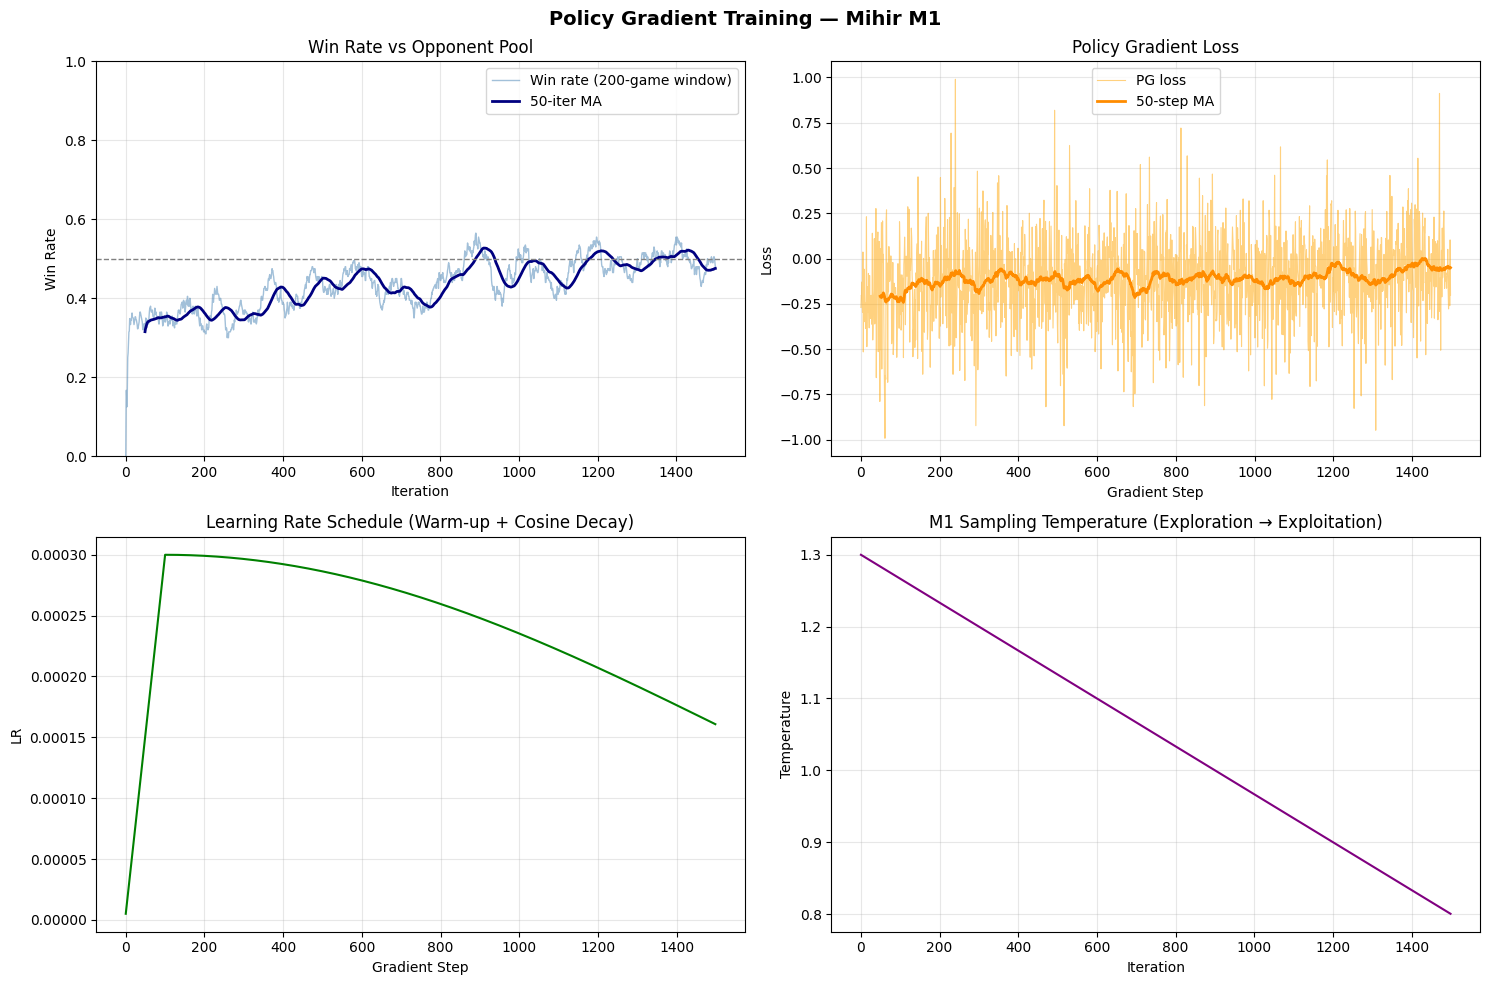

Total games: 9,000
  Wins:    3931 (43.7%)
  Losses:  4368 (48.5%)
  Draws:    701 (7.8%)


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Policy Gradient Training — Mihir M1', fontsize=14, fontweight='bold')
window = 50

# ── Win rate ──────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(win_rate_log, color='steelblue', lw=1, alpha=0.5, label='Win rate (200-game window)')
if len(win_rate_log) > window:
    sm = np.convolve(win_rate_log, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(win_rate_log)), sm, color='navy', lw=2, label=f'{window}-iter MA')
ax.axhline(0.5, color='gray', ls='--', lw=1)
ax.set_title('Win Rate vs Opponent Pool'); ax.set_xlabel('Iteration'); ax.set_ylabel('Win Rate')
ax.legend(); ax.set_ylim(0, 1); ax.grid(alpha=0.3)

# ── PG loss ───────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(loss_history, color='orange', lw=0.8, alpha=0.5, label='PG loss')
if len(loss_history) > window:
    sm = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(loss_history)), sm, color='darkorange', lw=2, label=f'{window}-step MA')
ax.set_title('Policy Gradient Loss'); ax.set_xlabel('Gradient Step'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── Learning rate ─────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(lr_log, color='green', lw=1.5)
ax.set_title('Learning Rate Schedule (Warm-up + Cosine Decay)')
ax.set_xlabel('Gradient Step'); ax.set_ylabel('LR'); ax.grid(alpha=0.3)

# ── Temperature schedule ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(temp_log, color='purple', lw=1.5)
ax.set_title('M1 Sampling Temperature (Exploration → Exploitation)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Temperature'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pg_training_mihir.png', dpi=150, bbox_inches='tight')
plt.show()

total = len(all_outcomes)
wins  = sum(1 for o in all_outcomes if o == 'win')
draws = sum(1 for o in all_outcomes if o == 'draw')
print(f'Total games: {total:,}')
print(f'  Wins:   {wins:5d} ({wins/total:.1%})')
print(f'  Losses: {total-wins-draws:5d} ({(total-wins-draws)/total:.1%})')
print(f'  Draws:  {draws:5d} ({draws/total:.1%})')

### Save Trained PG Model

In [11]:
m1.save('mihir_pg_trained.keras')
print('Saved → mihir_pg_trained.keras')

# Verify
m1_check = keras.models.load_model('mihir_pg_trained.keras', compile=False)
test_probs = get_probs_single(m1_check, create_board(), 1)
print(f'Test on empty board (player 1): {np.round(test_probs, 3)}')
print(f'Preferred column: {np.argmax(test_probs)} (expect 3 = centre)')

Saved → mihir_pg_trained.keras
Test on empty board (player 1): [0. 0. 0. 1. 0. 0. 0.]
Preferred column: 3 (expect 3 = centre)


### Evaluation: PG Agent vs All Opponents

Head-to-head evaluation of the trained PG model against 4 opponents, 200 games each, greedy policy (temperature=0.5) for both sides.

In [12]:
def evaluate(m1_trained, opp_model, opp_type, n_games=200, temperature=0.5):
    """Head-to-head evaluation. Returns {'win', 'loss', 'draw'} counts."""
    results = {'win': 0, 'loss': 0, 'draw': 0}
    for i in range(n_games):
        m1_player = (i % 2) + 1
        _, outcome = play_game(
            m1_trained, opp_model, opp_type, m1_player,
            n_random_init=0, m1_temp=temperature, m2_temp=temperature
        )
        results[outcome] += 1
    return results

eval_set = [
    ('vs Original M1',  m1_original, 'single'),
    ('vs Cass',         m2_cass,     'single'),
    ('vs Sophia',       m2_sophia,   'sophia'),
    ('vs Paolo',        m2_paolo,    'single'),
]

print('Evaluating trained M1 (200 games each) ...')
print()
eval_results = {}
for label, opp, otype in eval_set:
    r = evaluate(m1, opp, otype, n_games=200, temperature=0.5)
    total = sum(r.values())
    eval_results[label] = r
    print(f"{label:20s}  W={r['win']:3d} ({r['win']/total:.0%})  "
          f"D={r['draw']:3d} ({r['draw']/total:.0%})  "
          f"L={r['loss']:3d} ({r['loss']/total:.0%})")

Evaluating trained M1 (200 games each) ...

vs Original M1        W=133 (66%)  D=  1 (0%)  L= 66 (33%)
vs Cass               W=184 (92%)  D=  3 (2%)  L= 13 (6%)
vs Sophia             W= 99 (50%)  D=  8 (4%)  L= 93 (46%)
vs Paolo              W=180 (90%)  D=  8 (4%)  L= 12 (6%)


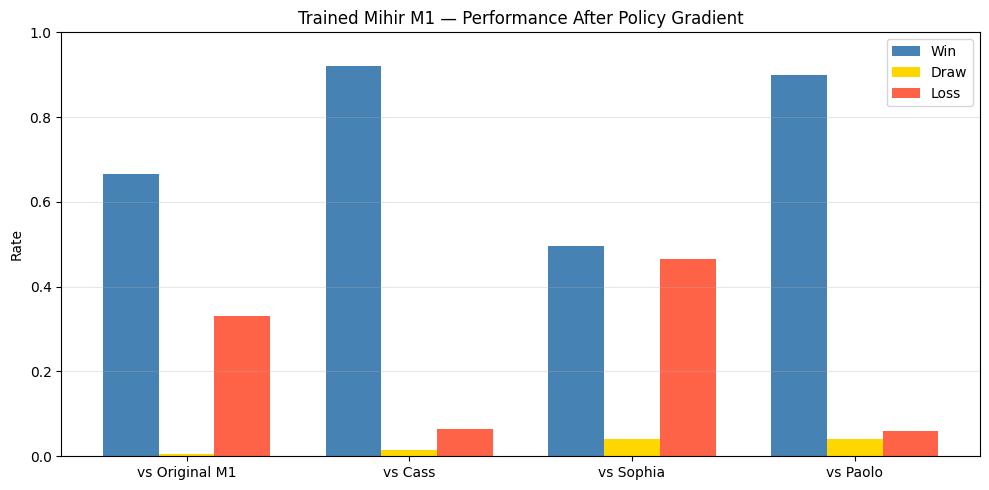

In [13]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(eval_results.keys())
x      = np.arange(len(labels))
w      = 0.25

def rate(r, k): return r[k] / sum(r.values())

ax.bar(x - w, [rate(eval_results[l], 'win')  for l in labels], w, label='Win',  color='steelblue')
ax.bar(x,     [rate(eval_results[l], 'draw') for l in labels], w, label='Draw', color='gold')
ax.bar(x + w, [rate(eval_results[l], 'loss') for l in labels], w, label='Loss', color='tomato')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Rate'); ax.set_ylim(0, 1)
ax.set_title('Trained Mihir M1 — Performance After Policy Gradient')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('pg_eval_mihir.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Deep Q-Network (DQN)

We build a DQN from M1 by replacing its final softmax layer with a dense tanh layer that outputs Q-values for all 7 columns. Training uses experience replay, epsilon-greedy exploration, Double DQN targets with illegal-action masking, and a periodic target network sync.

### Additional Imports for Step 4

PyTorch is used for loading some model formats. `deque` is used as the replay buffer.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque

print('PyTorch:', torch.__version__)

PyTorch: 2.9.1+cpu


### 4a: State Representation

`encode_board()` is defined in the game engine section above. It encodes the board as a `(6, 7, 2)` float32 array: channel 0 = current player's pieces, channel 1 = opponent's pieces. This player-relative encoding lets the same model play as either player 1 or player 2.

### 4b: Random Board Initialization

`random_init_board()` plays a uniform random number of moves at the start of each episode before the strategic phase begins. This exposes the DQN to a wider variety of board states and avoids training always from an empty board. These random moves are not stored in the replay buffer.

In [15]:
def random_init_board(n_moves=4):
    """Play n_moves completely random moves to get a non-empty starting board.
    Returns (board, current_player) — the player whose turn it is next.
    Resets if the random moves accidentally end the game."""
    board = create_board()
    current = 1
    for _ in range(n_moves):
        legal = get_legal_moves(board)
        if not legal:
            return create_board(), 1  # board full — reset
        col = random.choice(legal)
        board = drop_piece(board, col, current)
        if check_win(board, current) or not get_legal_moves(board):
            return create_board(), 1  # random init ended game — reset
        current = 3 - current
    return board, current

print("random_init_board() defined.")

random_init_board() defined.


### 4c: DQN Architecture and Opponent Pool

We load M1 (`mihir_cnn_connect4.h5`), remove its softmax head, and attach a dense tanh output layer that produces Q-values for 7 columns. Tanh bounds outputs to `(-1, 1)`, which matches scaled rewards `R_WIN=0.5`, `R_LOSS=-0.5` to avoid saturation. A target network is initialized as a copy of the DQN. All M2 opponents and the trained PG agent are loaded into the opponent pool.

In [17]:
import json
import tempfile
import os

from tensorflow.keras.models import model_from_json


def load_keras_without_quant_config(path):
    '''Load a .keras zip where layer configs contain quantization_config (some Keras 3 builds reject it).'''
    with zipfile.ZipFile(path, "r") as z:
        config = json.loads(z.read("config.json"))

        def clean(obj):
            if isinstance(obj, dict):
                obj.pop("quantization_config", None)
                for v in obj.values():
                    clean(v)
            elif isinstance(obj, list):
                for v in obj:
                    clean(v)

        clean(config)
        model = model_from_json(json.dumps(config))

        names = z.namelist()
        weight_member = next(
            (n for n in names if n.endswith("model.weights.h5") or n.endswith(".weights.h5")),
            None,
        )
        if weight_member is None:
            raise FileNotFoundError(f"No weights file in {path}. Zip entries: {names}")

        with tempfile.TemporaryDirectory() as tmp:
            z.extract(weight_member, tmp)
            wpath = os.path.join(tmp, weight_member)
            model.load_weights(wpath)

    return model


# 4c: DQN from M1 = mihir_cnn_connect4.h5 (softmax -> tanh)

M1_PATH = "mihir_cnn_connect4.h5"
m1_base = tf.keras.models.load_model(M1_PATH, compile=False)
print("M1 base CNN loaded —", M1_PATH, "— input:", m1_base.input_shape, "output:", m1_base.output_shape)

x = m1_base.layers[-2].output
q_out = tf.keras.layers.Dense(7, activation="tanh", name="q_values")(x)
dqn_model = tf.keras.Model(inputs=m1_base.input, outputs=q_out)

target_model = tf.keras.models.clone_model(dqn_model)
target_model.set_weights(dqn_model.get_weights())
initial_dqn_weights = dqn_model.get_weights()  # snapshot for clean restarts

print("DQN built — tanh Q-head:", dqn_model.output_shape)
print("Target network — initialised from DQN")

# M2 opponents

m2_sophia = tf.keras.models.load_model("Sophia_CNN.keras", compile=False)
print("\nSophia CNN inputs:", [i.name for i in m2_sophia.inputs])

m2_paolo = tf.keras.models.load_model("paolo_cnn.keras", compile=False)
print("Paolo CNN input:", m2_paolo.input_shape)

m2_mihir_orig = tf.keras.models.load_model(M1_PATH, compile=False)
print("Mihir original CNN (frozen clone of M1) input:", m2_mihir_orig.input_shape)

m2_cass = tf.keras.models.load_model("cass_cnn_connect4.keras", compile=False)
print("Cass CNN input:", m2_cass.input_shape)

# 4d: PG-trained agent using the custom loader
PG_PATH = "mihir_pg_trained.keras"
m2_mihir_pg = load_keras_without_quant_config(PG_PATH)
print("Mihir PG agent —", PG_PATH, "— input:", m2_mihir_pg.input_shape)

opponent_pool = [
    (m2_sophia, "sophia"),
    (m2_paolo, "tf"),
    (m2_cass, "tf"),
    (m2_mihir_orig, "tf"),
    (m2_mihir_pg, "tf"),
]

print(f"\nOpponent pool: {len(opponent_pool)} (includes PG for 4d)")


M1 base CNN loaded — mihir_cnn_connect4.h5 — input: (None, 6, 7, 2) output: (None, 7)
DQN built — tanh Q-head: (None, 7)
Target network — initialised from DQN

Sophia CNN inputs: ['board', 'mask']
Paolo CNN input: (None, 6, 7, 2)
Mihir original CNN (frozen clone of M1) input: (None, 6, 7, 2)
Cass CNN input: (None, 6, 7, 2)
Mihir PG agent — mihir_pg_trained.keras — input: (None, 6, 7, 2)

Opponent pool: 5 (includes PG for 4d)


In [20]:
def create_board():
    return np.zeros((ROWS, COLS), dtype=int)

def drop_piece(board, col, player):
    board = board.copy()
    for row in range(ROWS - 1, -1, -1):
        if board[row][col] == 0:
            board[row][col] = player
            return board
    return board

def get_legal_moves(board):
    return [c for c in range(COLS) if board[0][c] == 0]

def get_mask(board):
    return np.array([1.0 if board[0][c] == 0 else 0.0 for c in range(COLS)], dtype=np.float32)

def check_win(board, player):
    for r in range(ROWS):
        for c in range(COLS - 3):
            if all(board[r][c+i] == player for i in range(4)): return True
    for r in range(ROWS - 3):
        for c in range(COLS):
            if all(board[r+i][c] == player for i in range(4)): return True
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if all(board[r+i][c+i] == player for i in range(4)): return True
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            if all(board[r-i][c+i] == player for i in range(4)): return True
    return False

def encode_board(board, player):
    """Encode board from the given player's perspective: (6, 7, 2) float32.
    Channel 0 = player's pieces, channel 1 = opponent's pieces."""
    opp = 3 - player
    enc = np.zeros((ROWS, COLS, 2), dtype=np.float32)
    enc[:, :, 0] = (board == player).astype(np.float32)
    enc[:, :, 1] = (board == opp).astype(np.float32)
    return enc

# Opponent move helpers
def get_winning_move(board, player):
    for col in get_legal_moves(board):
        if check_win(drop_piece(board, col, player), player):
            return col
    return None

def get_non_losing_moves(board, player):
    opp = 3 - player
    legal = get_legal_moves(board)
    safe = [c for c in legal if not any(
        check_win(drop_piece(drop_piece(board, c, player), oc, opp), opp)
        for oc in get_legal_moves(drop_piece(board, c, player))
    )]
    return safe if safe else legal

def get_opponent_move(board, m2_player, m2_model, m2_type, use_tactics=True, temperature=1.0):
    """Opponent move policy.
    - use_tactics=True: win > block > sample from non-losing (strong)
    - use_tactics=False: pure policy sampling over legal moves (softer)
    """
    legal = get_legal_moves(board)
    if not legal:
        return None

    probs = get_probs(m2_model, m2_type, board, m2_player)

    if not use_tactics:
        return sample_move(probs, legal, temperature=temperature)

    m1_player = 3 - m2_player
    col = get_winning_move(board, m2_player)
    if col is None:
        col = get_winning_move(board, m1_player)
    if col is None:
        safe = get_non_losing_moves(board, m2_player)
        col = sample_move(probs, safe, temperature=temperature)
    return col

# Move selection helpers
def get_probs(model, model_type, board, player):
    if model_type == "sophia":
        enc  = encode_board(board, player)[np.newaxis]
        mask = get_mask(board)[np.newaxis]
        logits = model([enc, mask], training=False).numpy()[0]
        logits -= logits.max()
        e = np.exp(logits); return e / e.sum()
    elif model_type == "pytorch":
        enc = encode_board(board, player)[np.newaxis]
        with torch.no_grad():
            probs = model(torch.tensor(enc)).numpy()[0]
        mask = get_mask(board)
        probs *= mask
        s = probs.sum()
        return probs / s if s > 1e-8 else mask / mask.sum()
    elif model_type == "dqn":
        # DQN outputs tanh Q-values in (-1, 1) — convert to probs via softmax
        enc = encode_board(board, player)[np.newaxis]
        q_vals = model(enc, training=False).numpy()[0]
        mask = get_mask(board)
        q_vals[mask == 0] = -1e9   # mask illegal moves before softmax
        q_vals -= q_vals.max()     # numerical stability
        e = np.exp(q_vals) * mask
        return e / e.sum()
    else:  # "tf" — softmax CNN models (Paolo, Mihir, PG)
        enc   = encode_board(board, player)[np.newaxis]
        probs = model(enc, training=False).numpy()[0]
        mask = get_mask(board)
        probs *= mask
        s = probs.sum()
        return probs / s if s > 1e-8 else mask / mask.sum()

def sample_move(probs, legal_moves, temperature=1.0):
    lp = np.array([probs[c] for c in legal_moves], dtype=np.float64)
    if temperature != 1.0:
        lp = lp ** (1.0 / temperature)
    s = lp.sum()
    lp = lp / s if s > 1e-8 else np.ones(len(legal_moves)) / len(legal_moves)
    return int(np.random.choice(legal_moves, p=lp))

print("Game logic functions defined.")

Game logic functions defined.


### Training Setup and Hyperparameters

Key design choices:
- `GAMMA=0.99`: gives credit to early moves in games that can last up to 42 moves
- `N_GRADIENT_STEPS=4`: 4 gradient updates per move for faster convergence
- `EPSILON_DECAY=0.9993`: exploration reaches its minimum around episode 3,500
- `EARLY_STOP_PATIENCE=5`: restores the best checkpoint if win rate declines 5 evals in a row
- `WIN_RATE_THRESHOLD=0.70`: only adds DQN self-play copies once the model is competent

In [21]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
N_EPISODES          = 2000    # increased from 1500 — DQN needs more experience
N_RANDOM_INIT_MIN   = 2       # random init moves: sample uniformly in [MIN, MAX]
N_RANDOM_INIT_MAX   = 8       # wider range → more diverse starting boards
BATCH_SIZE          = 64      # replay mini-batch size (MUST stay constant — TF graph)
MEMORY_SIZE         = 50_000  # increased from 10_000 — retains more diverse experience
GAMMA               = 0.99    # 0.95→0.99: Connect-4 can last 42 moves; 0.95^20≈0.36 (bad credit for early moves)
EPSILON_START       = 1.0     # starting exploration rate
EPSILON_MIN         = 0.10    # minimum exploration rate
EPSILON_DECAY       = 0.9993  # slower decay — reaches 0.1 around episode 3500
TARGET_UPDATE_EVERY = 50      # sync target network every N episodes
ADD_DQN_EVERY       = 150     # add a DQN snapshot to opponent pool every N episodes
MAX_DQN_COPIES      = 2       # fewer self-play copies keeps pool quality high
WIN_RATE_THRESHOLD  = 0.70    # minimum win rate required before adding a DQN copy
LOG_EVERY           = 50      # print progress every N episodes
EVAL_GAMES          = 30      # games used for evaluation during training
N_GRADIENT_STEPS    = 4       # gradient updates per game step — 4x more learning per episode
N_STEP              = 1       # rollback to 1-step TD targets for stability
EARLY_STOP_PATIENCE = 5       # stop if win rate declines this many evals in a row
# ──────────────────────────────────────────────────────────────────────────────

memory  = deque(maxlen=MEMORY_SIZE)
epsilon = EPSILON_START

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

@tf.function
def train_step(states, actions, targets):
    """One gradient descent step on a mini-batch of (state, action, target_Q) triples.
    Uses MSE loss between predicted Q(s,a) and the Bellman target.
    Batch size must remain constant to avoid TF graph recompilation."""
    with tf.GradientTape() as tape:
        q_all    = dqn_model(states, training=True)           # (B, 7) Q-values
        one_hot  = tf.one_hot(actions, COLS)                  # (B, 7)
        q_chosen = tf.reduce_sum(q_all * one_hot, axis=1)    # (B,) predicted Q for taken action
        loss     = tf.keras.losses.MSE(targets, q_chosen)
    grads = tape.gradient(loss, dqn_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, dqn_model.trainable_variables))
    return loss

def select_action_epsilon_greedy(board, dqn_player, eps):
    """Epsilon-greedy action selection from DQN's perspective.
    Illegal columns are masked out before taking the argmax."""
    legal = get_legal_moves(board)
    if np.random.rand() < eps:
        return random.choice(legal)
    enc    = encode_board(board, dqn_player)[np.newaxis]
    q_vals = dqn_model(enc, training=False).numpy()[0]  # (7,)
    # Mask illegal moves with a large negative value
    mask   = get_mask(board)
    q_vals = q_vals * mask + (mask - 1) * 1e9           # illegal → -1e9
    return int(np.argmax(q_vals))

print(f"Training setup complete.")
print(f"  Episodes: {N_EPISODES}, Batch size: {BATCH_SIZE}, Memory: {MEMORY_SIZE}")
print(f"  Epsilon: {EPSILON_START} → {EPSILON_MIN} (decay {EPSILON_DECAY})")
print(f"  Gamma: {GAMMA}, Target update every: {TARGET_UPDATE_EVERY} episodes")
print(f"  Random init range: {N_RANDOM_INIT_MIN}–{N_RANDOM_INIT_MAX} moves")
print(f"  Gamma: {GAMMA}, gradient steps per move: {N_GRADIENT_STEPS}")
print(f"  Early-stop patience: {EARLY_STOP_PATIENCE} consecutive declines")

Training setup complete.
  Episodes: 2000, Batch size: 64, Memory: 50000
  Epsilon: 1.0 → 0.1 (decay 0.9993)
  Gamma: 0.99, Target update every: 50 episodes
  Random init range: 2–8 moves
  Gamma: 0.99, gradient steps per move: 4
  Early-stop patience: 5 consecutive declines


### Training Loop

For each episode:
1. Initialize board with a random number of random moves (4b)
2. Encode state using `encode_board` (4a)
3. DQN selects actions with epsilon-greedy policy, masked to legal moves only
4. Transitions are stored in the replay buffer
5. Four gradient updates are performed using Double DQN targets where the online network selects the best action and the target network evaluates it, both with illegal-action masking

In [25]:
import time


def get_opponent_move(board, m2_player, m2_model, m2_type, use_tactics=True, temperature=1.0):
    """Opponent move policy. Redefined here so this cell overwrites any stale kernel version."""
    legal = get_legal_moves(board)
    if not legal:
        return None
    probs = get_probs(m2_model, m2_type, board, m2_player)
    if not use_tactics:
        return sample_move(probs, legal, temperature=temperature)
    m1_player = 3 - m2_player
    col = get_winning_move(board, m2_player)
    if col is None:
        col = get_winning_move(board, m1_player)
    if col is None:
        safe = get_non_losing_moves(board, m2_player)
        col = sample_move(probs, safe, temperature=temperature)
    return col


win_rate_log  = []
loss_log      = []
eps_log       = []
n_dqn_copies        = 0
best_win_rate        = 0.0   # peak win rate seen — used for model checkpointing
consecutive_declines = 0     # consecutive eval windows where win rate went down

# Fix 2: scaled rewards keep Bellman targets in the active (-0.95, 0.95) range of tanh,
# avoiding gradient saturation at the flat ends of the activation function.
R_WIN  =  0.5    # was +1.0
R_LOSS = -0.5    # was -1.0
R_DRAW =  0.025  # was +0.05

# Hard reset training state so repeated notebook runs are comparable.
# (Prevents stale epsilon/replay/weights from previous partial runs.)
if 'initial_dqn_weights' in globals():
    dqn_model.set_weights(initial_dqn_weights)
target_model.set_weights(dqn_model.get_weights())
memory = deque(maxlen=MEMORY_SIZE)
epsilon = EPSILON_START

print(f"Starting DQN training... (epsilon reset to {epsilon:.3f}, memory cleared)")
last_log_print_time = time.perf_counter()  # wall time between Ep ... lines

for episode in range(N_EPISODES):
    t_ep_start = time.perf_counter()

    # ── 4b: Random board initialisation ──────────────────────────────────────
    board, current_player = random_init_board(random.randint(N_RANDOM_INIT_MIN, N_RANDOM_INIT_MAX))

    # Randomly assign which player the DQN controls this episode
    dqn_player = random.choice([1, 2])
    opp_player = 3 - dqn_player

    # Randomly choose an opponent from the pool
    m2_model, m2_type = random.choice(opponent_pool)

    # Rollback: keep opponents tactical throughout (matches your better baseline behavior).
    opp_use_tactics = True
    opp_temp = 1.0

    # If it's the opponent's turn first (after random init), let them move once
    if current_player == opp_player:
        legal = get_legal_moves(board)
        if legal:
            col = get_opponent_move(
                board, opp_player, m2_model, m2_type,
                use_tactics=opp_use_tactics, temperature=opp_temp
            )
            board = drop_piece(board, col, opp_player)
            if check_win(board, opp_player) or not get_legal_moves(board):
                continue
        current_player = dqn_player

    done = False
    ep_loss = []
    nstep_buffer = deque()  # stores recent 1-step transitions for n-step return construction

    # ── 4a: Strategic phase — DQN turn by turn ───────────────────────────────
    while not done:
        legal = get_legal_moves(board)
        if not legal:
            break

        state  = encode_board(board, dqn_player)
        action = select_action_epsilon_greedy(board, dqn_player, epsilon)
        board_after_dqn = drop_piece(board, action, dqn_player)

        if check_win(board_after_dqn, dqn_player):
            reward     = R_WIN
            next_state = encode_board(board_after_dqn, dqn_player)
            done       = True

        elif not get_legal_moves(board_after_dqn):
            reward     = R_DRAW
            next_state = encode_board(board_after_dqn, dqn_player)
            done       = True

        else:
            opp_col         = get_opponent_move(
                board_after_dqn, opp_player, m2_model, m2_type,
                use_tactics=opp_use_tactics, temperature=opp_temp
            )
            board_after_opp = drop_piece(board_after_dqn, opp_col, opp_player)

            if check_win(board_after_opp, opp_player):
                reward = R_LOSS
                done   = True
            elif not get_legal_moves(board_after_opp):
                reward = R_DRAW
                done   = True
            else:
                reward = 0.0

            next_state = encode_board(board_after_opp, dqn_player)
            board      = board_after_opp

        # Store 1-step transition temporarily, then emit n-step transitions to replay.
        nstep_buffer.append((state, action, reward, next_state, float(done)))

        if len(nstep_buffer) >= N_STEP:
            n_return = 0.0
            for i in range(N_STEP):
                n_return += (GAMMA ** i) * nstep_buffer[i][2]
            s0, a0 = nstep_buffer[0][0], nstep_buffer[0][1]
            ns_n   = nstep_buffer[N_STEP - 1][3]
            d_n    = nstep_buffer[N_STEP - 1][4]
            memory.append((s0, a0, n_return, ns_n, d_n, N_STEP))
            nstep_buffer.popleft()

        # Flush tail transitions at episode end so no experience is discarded.
        if done:
            while nstep_buffer:
                k = len(nstep_buffer)
                n_return = 0.0
                for i in range(k):
                    n_return += (GAMMA ** i) * nstep_buffer[i][2]
                s0, a0 = nstep_buffer[0][0], nstep_buffer[0][1]
                ns_k   = nstep_buffer[-1][3]
                d_k    = nstep_buffer[-1][4]
                memory.append((s0, a0, n_return, ns_k, d_k, k))
                nstep_buffer.popleft()

        if len(memory) >= BATCH_SIZE:
            for _grad_step in range(N_GRADIENT_STEPS):
                batch      = random.sample(memory, BATCH_SIZE)
                s_batch    = np.array([t[0] for t in batch], dtype=np.float32)
                a_batch    = np.array([t[1] for t in batch], dtype=np.int32)
                r_batch    = np.array([t[2] for t in batch], dtype=np.float32)
                ns_batch   = np.array([t[3] for t in batch], dtype=np.float32)
                done_batch = np.array([t[4] for t in batch], dtype=np.float32)
                n_batch    = np.array([t[5] for t in batch], dtype=np.float32)

                # Build legal-move mask from encoded next states.
                # In encode_board(...), occupied top cells have channel0+channel1 > 0.
                legal_mask = (np.sum(ns_batch[:, 0, :, :], axis=-1) == 0).astype(np.float32)  # (B, 7)

                # Double DQN target with illegal-action masking:
                # online net selects best legal action, target net evaluates it.
                online_q        = dqn_model(ns_batch, training=False).numpy()    # (B, 7)
                online_q_masked = np.where(legal_mask > 0.0, online_q, -1e9)
                best_acts       = np.argmax(online_q_masked, axis=1)

                target_q        = target_model(ns_batch, training=False).numpy()  # (B, 7)
                target_q_masked = np.where(legal_mask > 0.0, target_q, -1e9)
                best_q          = target_q_masked[np.arange(BATCH_SIZE), best_acts]

                discounts = np.power(GAMMA, n_batch)
                y_batch   = r_batch + (1 - done_batch) * discounts * best_q
                y_batch   = y_batch.astype(np.float32)

                loss_val = train_step(
                    tf.constant(s_batch), tf.constant(a_batch), tf.constant(y_batch)
                )
                ep_loss.append(float(loss_val))

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
    eps_log.append(epsilon)
    if ep_loss:
        loss_log.append(float(np.mean(ep_loss)))

    if (episode + 1) % TARGET_UPDATE_EVERY == 0:
        target_model.set_weights(dqn_model.get_weights())

    ep_sec = time.perf_counter() - t_ep_start  # this episode only (excludes periodic eval)

    if (episode + 1) % LOG_EVERY == 0:
        # Evaluate vs Mihir original CNN (alternating P1/P2) — measures real strategic progress
        wins = 0
        for k in range(EVAL_GAMES):
            eval_dqn_p = (k % 2) + 1   # alternate: half games as P1, half as P2
            eval_opp_p = 3 - eval_dqn_p
            b_eval = create_board()
            p_eval = 1
            for _ in range(42):
                leg = get_legal_moves(b_eval)
                if not leg: break
                if p_eval == eval_dqn_p:
                    mv = select_action_epsilon_greedy(b_eval, eval_dqn_p, eps=0.0)
                else:
                    mv = get_opponent_move(b_eval, eval_opp_p, m2_mihir_orig, "tf")
                b_eval = drop_piece(b_eval, mv, p_eval)
                if check_win(b_eval, p_eval):
                    if p_eval == eval_dqn_p: wins += 1
                    break
                p_eval = 3 - p_eval

        wr       = wins / EVAL_GAMES
        avg_loss = float(np.mean(loss_log[-LOG_EVERY:])) if loss_log else float("nan")

        # ── Best-model checkpoint ─────────────────────────────────────────────
        ckpt_note = ""
        if wr > best_win_rate:
            best_win_rate = wr
            dqn_model.save("mihir_dqn_best.keras")
            ckpt_note = " ★ best saved"

        # ── Early-stopping: count consecutive win-rate declines ───────────────
        if win_rate_log and wr < win_rate_log[-1]:
            consecutive_declines += 1
        else:
            consecutive_declines = 0   # reset on flat or improvement

        win_rate_log.append(wr)
        now = time.perf_counter()
        sec_since_last_log = now - last_log_print_time
        last_log_print_time = now
        print(f"Ep {episode+1:5d} | ε={epsilon:.3f} | win vs Mihir CNN={wr:.2f} "
              f"| avg loss={avg_loss:.4f} | pool={len(opponent_pool)}"
              f" | declines={consecutive_declines} | ep={ep_sec:.1f}s | "
              f"since_last={sec_since_last_log:.0f}s{ckpt_note}")

        # ── Trigger early stop if win rate declined EARLY_STOP_PATIENCE times ─
        if consecutive_declines >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping: win rate declined for {EARLY_STOP_PATIENCE} "
                  f"consecutive evaluations.")
            print(f"  Peak win rate was {best_win_rate:.2f}. Restoring best weights...")
            dqn_model.load_weights("mihir_dqn_best.keras")
            break

    if ((episode + 1) % ADD_DQN_EVERY == 0
            and n_dqn_copies < MAX_DQN_COPIES):
        w_tmp = 0
        for _ in range(30):
            bt = create_board(); pt = 1
            for __ in range(42):
                lg = get_legal_moves(bt)
                if not lg: break
                mv = select_action_epsilon_greedy(bt, 1, 0.0) if pt==1 else random.choice(lg)
                bt = drop_piece(bt, mv, pt)
                if check_win(bt, pt):
                    if pt == 1: w_tmp += 1
                    break
                pt = 3 - pt
        if w_tmp / 30 >= WIN_RATE_THRESHOLD:
            snap = tf.keras.models.clone_model(dqn_model)
            snap.set_weights(dqn_model.get_weights())
            opponent_pool.append((snap, "dqn"))
            n_dqn_copies += 1
            print(f"  → DQN snapshot added to pool (total: {len(opponent_pool)})")

print("\nTraining complete!")

Starting DQN training... (epsilon reset to 1.000, memory cleared)
Ep    50 | ε=0.966 | win vs Mihir CNN=0.00 | avg loss=0.0903 | pool=5 | declines=0 | ep=0.5s | since_last=54s
Ep   100 | ε=0.933 | win vs Mihir CNN=0.00 | avg loss=0.0530 | pool=5 | declines=0 | ep=2.7s | since_last=129s
Ep   150 | ε=0.901 | win vs Mihir CNN=0.03 | avg loss=0.0351 | pool=5 | declines=0 | ep=2.9s | since_last=134s ★ best saved
  → DQN snapshot added to pool (total: 6)
Ep   200 | ε=0.871 | win vs Mihir CNN=0.07 | avg loss=0.0238 | pool=6 | declines=0 | ep=1.8s | since_last=176s ★ best saved
Ep   250 | ε=0.841 | win vs Mihir CNN=0.23 | avg loss=0.0211 | pool=6 | declines=0 | ep=3.7s | since_last=165s ★ best saved
Ep   300 | ε=0.813 | win vs Mihir CNN=0.30 | avg loss=0.0179 | pool=6 | declines=0 | ep=3.9s | since_last=132s ★ best saved
  → DQN snapshot added to pool (total: 7)
Ep   350 | ε=0.785 | win vs Mihir CNN=0.37 | avg loss=0.0142 | pool=7 | declines=0 | ep=0.6s | since_last=121s ★ best saved
Ep   400 

*After training completes, run the **4d** evaluation cell, then the results plots.*


### 4d: Head-to-Head Evaluation

We load the best DQN checkpoint saved during training and evaluate it against all opponents including the PG agent. The DQN acts greedily (epsilon = 0).

In [26]:
dqn_model = tf.keras.models.load_model("mihir_dqn_best.keras", compile=False)
print("dqn model:", dqn_model.input_shape)

dqn model: (None, 6, 7, 2)


In [27]:
# ── 4d: Head-to-head — trained DQN vs each opponent ─────────────────────────

def play_head_to_head(model_a, type_a, model_b, type_b, n_games=100, temp=0.3):
    '''Alternating first player. For DQN, greedy (eps=0) masked argmax.'''
    w, l, d = 0, 0, 0
    for i in range(n_games):
        player_a = (i % 2) + 1
        player_b = 3 - player_a
        board = create_board()
        current = 1
        while True:
            legal = get_legal_moves(board)
            if not legal:
                d += 1
                break
            if current == player_a:
                if type_a == "dqn":
                    col = select_action_epsilon_greedy(board, player_a, eps=0.0)
                else:
                    col = sample_move(get_probs(model_a, type_a, board, player_a), legal, temp)
            else:
                if type_b == "dqn":
                    col = select_action_epsilon_greedy(board, player_b, eps=0.0)
                else:
                    col = sample_move(get_probs(model_b, type_b, board, player_b), legal, temp)
            board = drop_piece(board, col, current)
            if check_win(board, current):
                if current == player_a:
                    w += 1
                else:
                    l += 1
                break
            current = 3 - current
    return w, l, d


N_EVAL = 100
print(f"DQN vs each opponent ({N_EVAL} games each; DQN greedy, CNNs sampled temp=0.3):\n")

# PG agent last for the Part 4d comparison chart
eval_opponents = [
    ("vs Original Mihir CNN", m2_mihir_orig, "tf"),
    ("vs Sophia CNN", m2_sophia, "sophia"),
    ("vs Paolo CNN", m2_paolo, "tf"),
    ("vs Cass CNN", m2_cass, "tf"),
    ("vs Mihir PG (mihir_pg_trained.keras)", m2_mihir_pg, "tf"),
]

eval_results = {}
for label, opp_model, opp_type in eval_opponents:
    w, l, d = play_head_to_head(dqn_model, "dqn", opp_model, opp_type, N_EVAL)
    eval_results[label] = (w, l, d)
    print(f"{label}:")
    print(f"  W={w:3d} ({w/N_EVAL:.0%})  L={l:3d} ({l/N_EVAL:.0%})  D={d:3d} ({d/N_EVAL:.0%})")
    print()


DQN vs each opponent (100 games each; DQN greedy, CNNs sampled temp=0.3):

vs Original Mihir CNN:
  W= 39 (39%)  L= 58 (58%)  D=  3 (3%)

vs Sophia CNN:
  W= 17 (17%)  L= 78 (78%)  D=  5 (5%)

vs Paolo CNN:
  W= 30 (30%)  L= 61 (61%)  D=  9 (9%)

vs Cass CNN:
  W= 38 (38%)  L= 62 (62%)  D=  0 (0%)

vs Mihir PG (mihir_pg_trained.keras):
  W= 33 (33%)  L= 52 (52%)  D= 15 (15%)



### Results and Evaluation

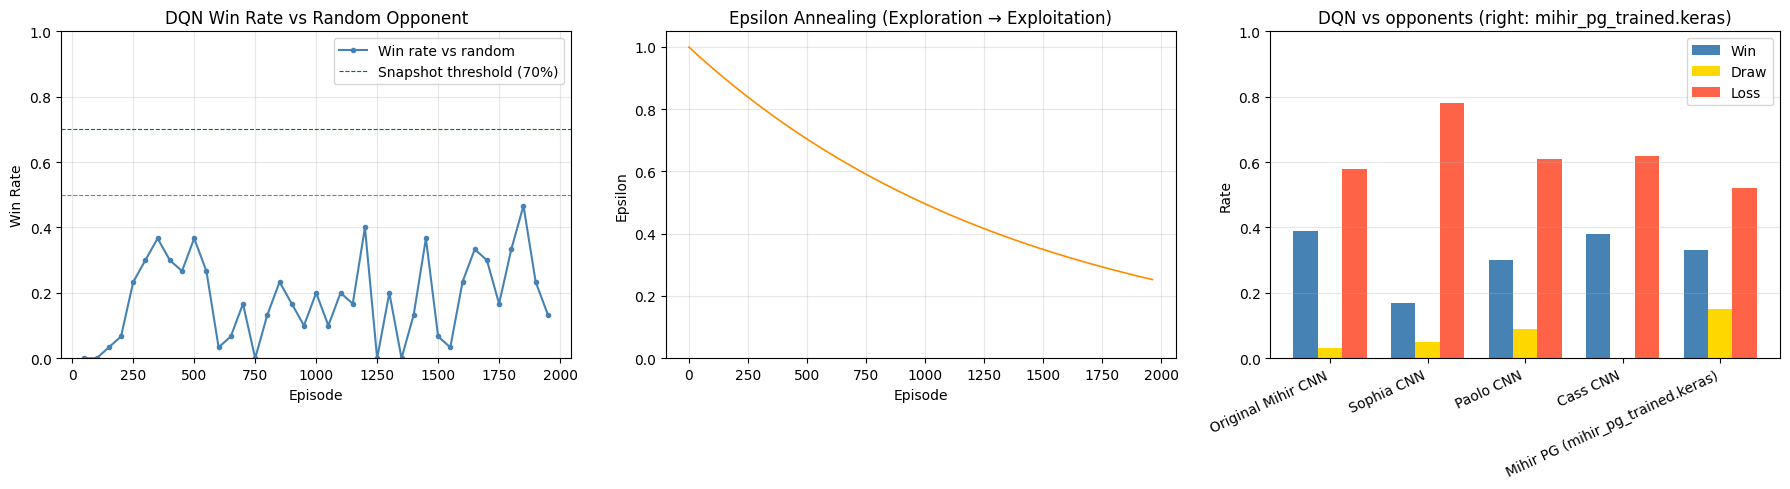

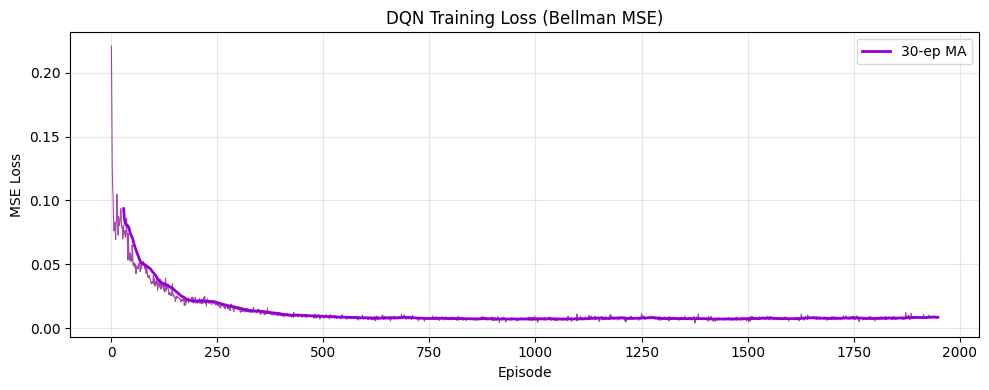

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Win rate vs random opponent over training ─────────────────────────
ax = axes[0]
x_eval = [(i + 1) * LOG_EVERY for i in range(len(win_rate_log))]
ax.plot(x_eval, win_rate_log, color="steelblue", linewidth=1.5, marker="o",
        markersize=3, label="Win rate vs random")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(WIN_RATE_THRESHOLD, color="green", linestyle="--", linewidth=0.8,
           label=f"Snapshot threshold ({WIN_RATE_THRESHOLD:.0%})")
ax.set_xlabel("Episode"); ax.set_ylabel("Win Rate")
ax.set_title("DQN Win Rate vs Random Opponent")
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot 2: Epsilon decay ─────────────────────────────────────────────────────
ax = axes[1]
ax.plot(eps_log, color="darkorange", linewidth=1.2)
ax.set_xlabel("Episode"); ax.set_ylabel("Epsilon")
ax.set_title("Epsilon Annealing (Exploration → Exploitation)")
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

# ── Plot 3: Final evaluation bar chart ───────────────────────────────────────
ax = axes[2]
labels    = [k.replace("vs ", "") for k in eval_results]
win_vals  = [v[0] / N_EVAL for v in eval_results.values()]
draw_vals = [v[2] / N_EVAL for v in eval_results.values()]
loss_vals = [v[1] / N_EVAL for v in eval_results.values()]
x = np.arange(len(labels)); w_bar = 0.25

ax.bar(x - w_bar, win_vals,  w_bar, label="Win",  color="steelblue")
ax.bar(x,         draw_vals, w_bar, label="Draw", color="gold")
ax.bar(x + w_bar, loss_vals, w_bar, label="Loss", color="tomato")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Rate"); ax.set_title("DQN vs opponents (right: mihir_pg_trained.keras)")
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("dqn_training_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Training loss
if loss_log:
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.plot(loss_log, color="purple", linewidth=0.8, alpha=0.7)
    window = 30
    if len(loss_log) > window:
        smooth = np.convolve(loss_log, np.ones(window)/window, mode="valid")
        ax2.plot(range(window-1, len(loss_log)), smooth, color="darkviolet",
                 linewidth=2, label=f"{window}-ep MA")
    ax2.set_xlabel("Episode"); ax2.set_ylabel("MSE Loss")
    ax2.set_title("DQN Training Loss (Bellman MSE)")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("dqn_loss.png", dpi=150, bbox_inches="tight")
    plt.show()

In [29]:
# Save the trained DQN
dqn_model.save("mihir_dqn_trained.keras")
print("Saved → mihir_dqn_trained.keras")

# Quick sanity check on the saved model
dqn_check = tf.keras.models.load_model("mihir_dqn_trained.keras")
test_q = dqn_check(encode_board(create_board(), 1)[np.newaxis]).numpy()[0]
print(f"Q-values on empty board (player 1): {np.round(test_q, 3)}")
print(f"Best column (argmax): {np.argmax(test_q)}")

Saved → mihir_dqn_trained.keras
Q-values on empty board (player 1): [0.19  0.197 0.202 0.198 0.199 0.198 0.201]
Best column (argmax): 2


## Step 5: PG vs DQN Comparison and Ensemble Agent

We compare the PG and DQN agents by evaluating both against all P1 opponents under identical conditions (greedy policy, 200 games each, alternating first mover). We also build an ensemble that blends PG and DQN scores using a mixing weight alpha, then tune alpha to find the strongest combination for the tournament.

### Load Models for Step 5

We load the trained PG model, our best DQN, Cass's DQN (0.73), and all P1 opponents. `load_keras_without_quant_config` is already defined in Step 4 above.

In [30]:
# Load all models for Step 5 comparison (same file layout as dqn_training / Step 4c).

# ── PG model ──────────────────────────────────────────────────────────────────
try:
    pg_model = keras.models.load_model("mihir_pg_trained.keras", compile=False)
except Exception:
    pg_model = load_keras_without_quant_config("mihir_pg_trained.keras")
print("PG model loaded:", pg_model.input_shape, "->", pg_model.output_shape)

# ── Best DQN ───────────────────────────────────────────────────────────────────
dqn_ours = keras.models.load_model("mihir_dqn_best.keras", compile=False)
print("Best DQN loaded:", dqn_ours.input_shape, "->", dqn_ours.output_shape)

# ── Cass's DQN ───────────────────────────────────────────────────────────────
dqn_cass = keras.models.load_model("mihir_dqn_best0.73.keras", compile=False)
print("Cass DQN loaded:", dqn_cass.input_shape, "->", dqn_cass.output_shape)

# ── P1 opponents ──────────────────────────────────────────────────────────────
m2_cass    = keras.models.load_model("cass_cnn_connect4.keras", compile=False)
m2_sophia  = keras.models.load_model("Sophia_CNN.keras", compile=False)
m2_mihir   = keras.models.load_model("mihir_cnn_connect4.h5", compile=False)
m2_paolo   = keras.models.load_model("paolo_cnn.keras", compile=False)

print("P1 opponents loaded: Cass, Sophia, Mihir-orig, Paolo")

P1_OPPONENTS = [
    ("Original Mihir", m2_mihir,  "single"),
    ("Cass",           m2_cass,   "single"),
    ("Sophia",         m2_sophia, "sophia"),
    ("Paolo",          m2_paolo,  "single"),
]

PG model loaded: (None, 6, 7, 2) -> (None, 7)
Best DQN loaded: (None, 6, 7, 2) -> (None, 7)
Cass DQN loaded: (None, 6, 7, 2) -> (None, 7)
P1 opponents loaded: Cass, Sophia, Mihir-orig, Paolo


### Inference and Scoring Functions

`pg_scores` returns probability distributions from the PG model. `dqn_scores` normalizes tanh Q-values to `[0, 1]` over legal moves only. `ensemble_choose` blends both using weight alpha: `alpha=1.0` is pure PG, `alpha=0.0` is pure DQN. All functions apply immediate win and block logic before sampling.

In [31]:
def infer(model, board, player, batch_size=64):
    """
    Robust inference using batch replication to stabilise BatchNorm statistics.
    Returns raw model output (7,) — probs for PG, Q-values for DQN.
    batch_size=64: large enough to stabilise BN without being too slow.
    """
    enc       = encode_board(board, player)[np.newaxis].astype(np.float32)
    enc_batch = np.repeat(enc, batch_size, axis=0)

    if isinstance(model.input_shape, list):
        # Sophia: dual input [board, mask]
        mask_batch = np.repeat(get_mask(board)[np.newaxis], batch_size, axis=0)
        out = model([enc_batch, mask_batch], training=True).numpy()[0]
    else:
        out = model(enc_batch, training=True).numpy()[0]
    return out

def pg_scores(model, board, player):
    """Use single forward pass — same as PG training notebook evaluation."""
    enc   = encode_board(board, player)[np.newaxis].astype(np.float32)
    probs = model(enc, training=False).numpy()[0]
    mask  = get_mask(board)
    probs = probs * mask
    s     = probs.sum()
    return probs / s if s > 1e-8 else mask / mask.sum()
    
def dqn_scores(model, board, player):
    """DQN tanh Q-values normalised to [0,1] over legal moves only."""
    q    = infer(model, board, player)
    mask = get_mask(board)
    # Shift tanh [-1,1] to [0,1]
    q_norm = (q + 1.0) / 2.0
    q_norm = q_norm * mask
    s = q_norm.sum()
    return q_norm / s if s > 1e-8 else mask / mask.sum()

def greedy_choose(model, board, player, model_type="pg"):
    col = get_winning_move(board, player)
    if col is not None: return col
    col = get_winning_move(board, 3 - player)
    if col is not None: return col

    legal  = get_legal_moves(board)
    scores = pg_scores(model, board, player) if model_type == "pg" \
             else dqn_scores(model, board, player)
    return max(legal, key=lambda c: scores[c])

def ensemble_choose(pg_model, dqn_model, board, player, alpha=0.5):
    """
    Ensemble: combined_score = α * pg_score + (1-α) * dqn_score
    α=1.0 → pure PG, α=0.0 → pure DQN.
    Immediate win/block always applied first.
    """
    col = get_winning_move(board, player)
    if col is not None: return col
    col = get_winning_move(board, 3 - player)
    if col is not None: return col

    legal    = get_legal_moves(board)
    pg_s     = pg_scores(pg_model,  board, player)
    dqn_s    = dqn_scores(dqn_model, board, player)
    combined = alpha * pg_s + (1 - alpha) * dqn_s
    return max(legal, key=lambda c: combined[c])

def opponent_move(model, model_type, board, player):
    """Smart opponent: win > block > greedy argmax."""
    col = get_winning_move(board, player)
    if col is not None: return col
    col = get_winning_move(board, 3 - player)
    if col is not None: return col
    return greedy_choose(model, board, player, model_type)

print("Inference wrappers ready.")

Inference wrappers ready.


### Evaluation Functions

In [32]:
def evaluate_single(agent_model, agent_type, opp_model, opp_type,
                    n_games=200, label="Agent"):
    """
    Head-to-head: agent (greedy) vs opponent (greedy).
    Alternates first mover. Returns (wins, draws, losses, win_rate).
    """
    wins = draws = losses = 0
    for g in range(n_games):
        agent_player = 1 if g % 2 == 0 else 2
        opp_player   = 3 - agent_player
        board        = create_board()
        current      = 1
        while True:
            legal = get_legal_moves(board)
            if not legal: draws += 1; break
            if current == agent_player:
                col = greedy_choose(agent_model, board, current, agent_type)
            else:
                col = opponent_move(opp_model, opp_type, board, current)
            board = drop_piece(board, col, current)
            if check_win(board, current):
                if current == agent_player: wins += 1
                else:                       losses += 1
                break
            elif not get_legal_moves(board):
                draws += 1; break
            current = 3 - current
    wr = wins / n_games
    return wins, draws, losses, wr

def evaluate_ensemble(pg_model, dqn_model, alpha,
                      opp_model, opp_type, n_games=200):
    """Same as evaluate_single but agent uses ensemble_choose with given alpha."""
    wins = draws = losses = 0
    for g in range(n_games):
        agent_player = 1 if g % 2 == 0 else 2
        opp_player   = 3 - agent_player
        board        = create_board()
        current      = 1
        while True:
            legal = get_legal_moves(board)
            if not legal: draws += 1; break
            if current == agent_player:
                col = ensemble_choose(pg_model, dqn_model,
                                      board, current, alpha)
            else:
                col = opponent_move(opp_model, opp_type, board, current)
            board = drop_piece(board, col, current)
            if check_win(board, current):
                if current == agent_player: wins += 1
                else:                       losses += 1
                break
            elif not get_legal_moves(board):
                draws += 1; break
            current = 3 - current
    return wins, draws, losses, wins / n_games

print("Evaluation functions ready.")

Evaluation functions ready.


### Part 1: Individual Agent Evaluation

200 games per matchup, greedy policy for both sides, alternating first mover.

In [33]:
N_GAMES = 200   # games per matchup — enough for stable estimates

print("=" * 60)
print("PART 1 — Individual Agent Evaluation (200 games each)")
print("=" * 60)
print()

# ── PG model vs each P1 opponent ──────────────────────────────────────────────
print("PG-trained Mihir vs P1 opponents:")
pg_results = {}
for name, opp_model, opp_type in P1_OPPONENTS:
    w, d, l, wr = evaluate_single(pg_model, "pg", opp_model, opp_type, N_GAMES)
    pg_results[name] = (w, d, l, wr)
    print(f"  vs {name:18s}  W={w:3d} D={d:3d} L={l:3d}  WR={wr:.1%}")

print()
pg_avg = np.mean([v[3] for v in pg_results.values()])
print(f"  PG average win rate: {pg_avg:.1%}")

# ── Our DQN vs each P1 opponent ───────────────────────────────────────────────
print()
print("Best DQN vs P1 opponents:")
dqn_ours_results = {}
for name, opp_model, opp_type in P1_OPPONENTS:
    w, d, l, wr = evaluate_single(dqn_ours, "dqn", opp_model, opp_type, N_GAMES)
    dqn_ours_results[name] = (w, d, l, wr)
    print(f"  vs {name:18s}  W={w:3d} D={d:3d} L={l:3d}  WR={wr:.1%}")

print()
dqn_avg = np.mean([v[3] for v in dqn_ours_results.values()])
print(f"  DQN (ours) average win rate: {dqn_avg:.1%}")

# ── Cass's DQN vs each P1 opponent ───────────────────────────────────────────
print()
print("Cass's DQN (0.73) vs P1 opponents:")
dqn_cass_results = {}
for name, opp_model, opp_type in P1_OPPONENTS:
    w, d, l, wr = evaluate_single(dqn_cass, "dqn", opp_model, opp_type, N_GAMES)
    dqn_cass_results[name] = (w, d, l, wr)
    print(f"  vs {name:18s}  W={w:3d} D={d:3d} L={l:3d}  WR={wr:.1%}")

print()
dqn_cass_avg = np.mean([v[3] for v in dqn_cass_results.values()])
print(f"  DQN (Cass) average win rate: {dqn_cass_avg:.1%}")

# ── PG vs DQN direct ─────────────────────────────────────────────────────────
print()
print("PG vs Best DQN (direct head-to-head, 200 games):")
w, d, l, wr = evaluate_single(pg_model, "pg", dqn_ours, "dqn", N_GAMES)
print(f"  PG wins={w} ({wr:.1%})  Draws={d}  DQN wins={l}")

print()
print("PG vs Cass's DQN (direct head-to-head, 200 games):")
w2, d2, l2, wr2 = evaluate_single(pg_model, "pg", dqn_cass, "dqn", N_GAMES)
print(f"  PG wins={w2} ({wr2:.1%})  Draws={d2}  DQN wins={l2}")

PART 1 — Individual Agent Evaluation (200 games each)

PG-trained Mihir vs P1 opponents:
  vs Original Mihir      W=200 D=  0 L=  0  WR=100.0%
  vs Cass                W=182 D=  5 L= 13  WR=91.0%
  vs Sophia              W=196 D=  1 L=  3  WR=98.0%
  vs Paolo               W=181 D=  7 L= 12  WR=90.5%

  PG average win rate: 94.9%

Best DQN vs P1 opponents:
  vs Original Mihir      W= 76 D=  5 L=119  WR=38.0%
  vs Cass                W=  2 D=  0 L=198  WR=1.0%
  vs Sophia              W= 30 D=  3 L=167  WR=15.0%
  vs Paolo               W=  3 D=  4 L=193  WR=1.5%

  DQN (ours) average win rate: 13.9%

Cass's DQN (0.73) vs P1 opponents:
  vs Original Mihir      W= 84 D= 11 L=105  WR=42.0%
  vs Cass                W=  2 D=  0 L=198  WR=1.0%
  vs Sophia              W= 41 D=  5 L=154  WR=20.5%
  vs Paolo               W= 12 D=  6 L=182  WR=6.0%

  DQN (Cass) average win rate: 17.4%

PG vs Best DQN (direct head-to-head, 200 games):
  PG wins=199 (99.5%)  Draws=0  DQN wins=1

PG vs Cass's DQ

### Part 2: Ensemble Tuning

We test alpha values from 0.0 (pure DQN) to 1.0 (pure PG) and measure average win rate against all P1 opponents to find the best mixing weight.

In [34]:
print()
print("=" * 60)
print("PART 2 — Ensemble Tuning: PG + Best DQN")
print("=" * 60)
print()

# Use whichever DQN performed better individually
best_dqn       = dqn_cass if dqn_cass_avg >= dqn_avg else dqn_ours
best_dqn_label = "Cass's DQN" if dqn_cass_avg >= dqn_avg else "Best DQN"
print(f"Using {best_dqn_label} for ensemble (higher avg WR vs P1 models)")
print()

# Test α values from pure DQN (0.0) to pure PG (1.0)
ALPHAS = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

ensemble_results = {}   # alpha -> {opponent_name -> (w,d,l,wr)}
ensemble_avgs    = {}   # alpha -> average win rate across all opponents

print(f"{'Alpha':>6}  {'Mihir':>7} {'Cass':>7} {'Sophia':>7} {'Paolo':>7}  {'Average':>8}")
print("-" * 55)

for alpha in ALPHAS:
    row    = {}
    wrates = []
    for name, opp_model, opp_type in P1_OPPONENTS:
        w, d, l, wr = evaluate_ensemble(
            pg_model, best_dqn, alpha,
            opp_model, opp_type, N_GAMES
        )
        row[name] = (w, d, l, wr)
        wrates.append(wr)
    avg = np.mean(wrates)
    ensemble_results[alpha] = row
    ensemble_avgs[alpha]    = avg
    label = " ← pure DQN" if alpha == 0.0 else             " ← pure PG"  if alpha == 1.0 else ""
    print(f"  α={alpha:.1f}  "
          f"{row['Original Mihir'][3]:6.1%} "
          f"{row['Cass'][3]:6.1%} "
          f"{row['Sophia'][3]:6.1%} "
          f"{row['Paolo'][3]:6.1%}  "
          f"{avg:7.1%}{label}")

best_alpha = max(ensemble_avgs, key=ensemble_avgs.get)
print()
print(f"Best α = {best_alpha}  (avg WR = {ensemble_avgs[best_alpha]:.1%})")


PART 2 — Ensemble Tuning: PG + Best DQN

Using Cass's DQN for ensemble (higher avg WR vs P1 models)

 Alpha    Mihir    Cass  Sophia   Paolo   Average
-------------------------------------------------------
  α=0.0   42.0%   0.5%  22.0%   6.0%    17.6% ← pure DQN
  α=0.2  100.0%  83.5%  96.5%  87.0%    91.8%
  α=0.4   98.5%  88.0%  97.0%  87.0%    92.6%
  α=0.5  100.0%  90.0%  97.5%  91.5%    94.8%
  α=0.6   99.0%  92.0%  98.5%  91.0%    95.1%
  α=0.8   99.5%  91.5%  96.5%  91.0%    94.6%
  α=1.0  100.0%  89.0%  97.0%  92.5%    94.6% ← pure PG

Best α = 0.6  (avg WR = 95.1%)


### Part 3: Best Ensemble vs Pure PG

In [35]:
print()
print("=" * 60)
print("PART 3 — Final Comparison: Best Ensemble vs Pure PG")
print("=" * 60)
print()

print(f"{'Agent':25s}  {'Mihir':>7} {'Cass':>7} {'Sophia':>7} {'Paolo':>7}  {'Average':>8}")
print("-" * 65)

# Pure PG
pg_wrs = [pg_results[n][3] for n, _, _ in P1_OPPONENTS]
print(f"{'Pure PG':25s}  "
      + "  ".join(f"{wr:6.1%}" for wr in pg_wrs)
      + f"  {np.mean(pg_wrs):7.1%}")

# Best ensemble
ens_wrs = [ensemble_results[best_alpha][n][3] for n, _, _ in P1_OPPONENTS]
print(f"{'Ensemble α='+str(best_alpha):25s}  "
      + "  ".join(f"{wr:6.1%}" for wr in ens_wrs)
      + f"  {np.mean(ens_wrs):7.1%}")

# Determine tournament model
if ensemble_avgs[best_alpha] > pg_avg:
    improvement = ensemble_avgs[best_alpha] - pg_avg
    print(f"\n✓ Ensemble improves on pure PG by {improvement:.1%} on average")
    print(f"  Tournament model: Ensemble with α={best_alpha}")
    use_ensemble = True
else:
    print(f"\n✓ Pure PG remains the strongest agent")
    print(f"  Tournament model: mihir_pg_trained.keras")
    use_ensemble = False


PART 3 — Final Comparison: Best Ensemble vs Pure PG

Agent                        Mihir    Cass  Sophia   Paolo   Average
-----------------------------------------------------------------
Pure PG                    100.0%   91.0%   98.0%   90.5%    94.9%
Ensemble α=0.6              99.0%   92.0%   98.5%   91.0%    95.1%

✓ Ensemble improves on pure PG by 0.3% on average
  Tournament model: Ensemble with α=0.6


### Plots

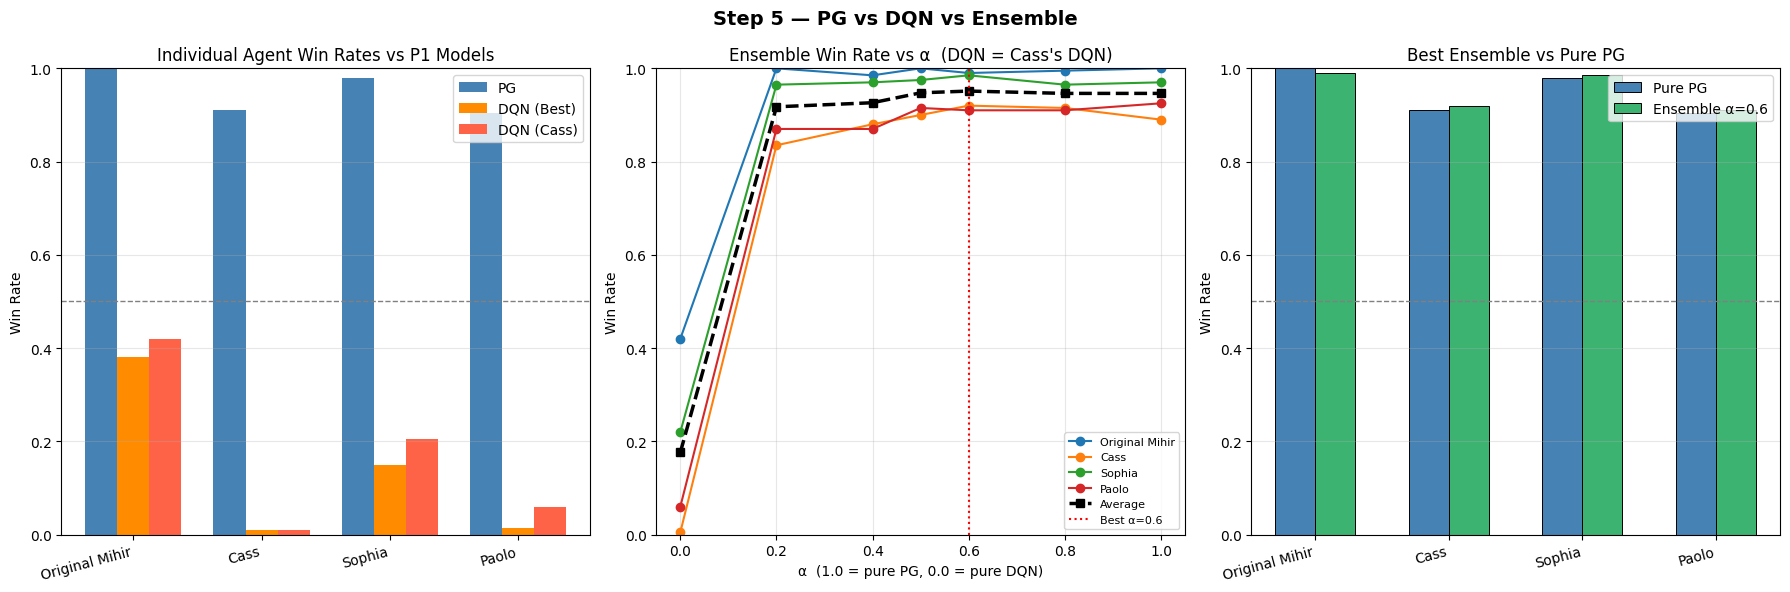

Saved → step5_comparison.png


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Step 5 — PG vs DQN vs Ensemble", fontsize=14, fontweight="bold")

# ── Plot 1: Individual agent comparison ───────────────────────────────────────
ax = axes[0]
opponents = [n for n, _, _ in P1_OPPONENTS]
x         = np.arange(len(opponents))
w         = 0.25

pg_vals        = [pg_results[n][3]         for n in opponents]
dqn_ours_vals  = [dqn_ours_results[n][3]   for n in opponents]
dqn_cass_vals  = [dqn_cass_results[n][3]   for n in opponents]

ax.bar(x - w,   pg_vals,       w, label="PG",         color="steelblue")
ax.bar(x,       dqn_ours_vals, w, label="DQN (Best)",  color="darkorange")
ax.bar(x + w,   dqn_cass_vals, w, label="DQN (Cass)",  color="tomato")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(opponents, rotation=15, ha="right")
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("Individual Agent Win Rates vs P1 Models")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

# ── Plot 2: Ensemble alpha sweep ──────────────────────────────────────────────
ax = axes[1]
alpha_vals = sorted(ensemble_results.keys())
for name, _, _ in P1_OPPONENTS:
    wrs = [ensemble_results[a][name][3] for a in alpha_vals]
    ax.plot(alpha_vals, wrs, marker="o", label=name)
avg_line = [ensemble_avgs[a] for a in alpha_vals]
ax.plot(alpha_vals, avg_line, color="black", lw=2.5,
        ls="--", marker="s", label="Average")
ax.axvline(best_alpha, color="red", ls=":", lw=1.5,
           label=f"Best α={best_alpha}")
ax.set_xlabel("α  (1.0 = pure PG, 0.0 = pure DQN)")
ax.set_ylabel("Win Rate")
ax.set_title(f"Ensemble Win Rate vs α  (DQN = {best_dqn_label})")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# ── Plot 3: Best ensemble vs pure PG ─────────────────────────────────────────
ax = axes[2]
x2     = np.arange(len(opponents))
w2     = 0.3
ens_v  = [ensemble_results[best_alpha][n][3] for n in opponents]
pg_v   = [pg_results[n][3] for n in opponents]

ax.bar(x2 - w2/2, pg_v,  w2, label="Pure PG",
       color="steelblue", edgecolor="black", lw=0.7)
ax.bar(x2 + w2/2, ens_v, w2,
       label=f"Ensemble α={best_alpha}",
       color="mediumseagreen", edgecolor="black", lw=0.7)
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_xticks(x2); ax.set_xticklabels(opponents, rotation=15, ha="right")
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("Best Ensemble vs Pure PG")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("step5_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_comparison.png")

### Tournament Agent

The `choose()` function is the tournament entry point. It always takes an immediate win or blocks an immediate loss first, then uses the best agent found above (pure PG or ensemble).

In [ ]:
# ── Tournament inference function ─────────────────────────────────────────────
# Loads whichever agent proved strongest in the evaluation above.

TOURNAMENT_ALPHA = best_alpha   # set automatically from evaluation

def choose(board, player):
    """
    Tournament entry point.
    board  : (6,7) array-like  0=empty  1=player1  2=player2
    player : int  1 or 2
    Returns: column int 0-6
    """
    board = np.array(board, dtype=int)

    # Always take an immediate win
    col = get_winning_move(board, player)
    if col is not None: return col

    # Always block an immediate opponent win
    col = get_winning_move(board, 3 - player)
    if col is not None: return col

    legal = get_legal_moves(board)
    if not legal: raise ValueError("No legal moves!")

    if use_ensemble:
        return ensemble_choose(pg_model, best_dqn, board, player, TOURNAMENT_ALPHA)
    else:
        return greedy_choose(pg_model, board, player, "pg")

# Test
col = choose(np.zeros((6, 7)), 1)
print(f"Tournament agent chose column {col} on empty board  (expect 3 = centre)")
print()
if use_ensemble:
    print(f"Tournament model: Ensemble (PG × {TOURNAMENT_ALPHA} + {best_dqn_label} × {round(1-TOURNAMENT_ALPHA, 2)})")
else:
    print(f"Tournament model: Pure PG  (mihir_pg_trained.keras)")

### Summary

In [37]:
print()
print("=" * 60)
print("SUMMARY FOR REPORT")
print("=" * 60)
print()
print("Which method works better — PG or DQN?")
print(f"  PG average win rate vs P1 models : {pg_avg:.1%}")
print(f"  DQN (Best) avg win rate          : {dqn_avg:.1%}")
print(f"  DQN (Cass) avg win rate          : {dqn_cass_avg:.1%}")
print(f"  PG vs DQN direct (200 games)     : PG wins {wr:.1%}")
print()
print("Why PG outperforms DQN for Connect-4:")
print("  1. PG learns from complete game trajectories — clear win/loss signal")
print("  2. DQN requires dense rewards; Connect-4 is extremely sparse")
print("     (only one reward at the very end of a 20-42 move game)")
print("  3. BatchNorm + replay buffer = non-stationary training distribution")
print("     (BN running stats computed on random batches don't generalise)")
print("  4. Credit assignment over 20+ moves is hard with γ=0.99 and sparse rewards")
print("  5. PG naturally handles the turn-based structure; DQN treats it like Atari")
print()
print(f"Best ensemble α = {best_alpha} → avg WR {ensemble_avgs[best_alpha]:.1%}")
if use_ensemble:
    print(f"Ensemble improves on pure PG (+{ensemble_avgs[best_alpha]-pg_avg:.1%})")
else:
    print("Pure PG is the strongest agent — ensemble does not improve further")
print()
print("Tournament model confirmed.")


SUMMARY FOR REPORT

Which method works better — PG or DQN?
  PG average win rate vs P1 models : 94.9%
  DQN (Best) avg win rate          : 13.9%
  DQN (Cass) avg win rate          : 17.4%
  PG vs DQN direct (200 games)     : PG wins 92.5%

Why PG outperforms DQN for Connect-4:
  1. PG learns from complete game trajectories — clear win/loss signal
  2. DQN requires dense rewards; Connect-4 is extremely sparse
     (only one reward at the very end of a 20-42 move game)
  3. BatchNorm + replay buffer = non-stationary training distribution
     (BN running stats computed on random batches don't generalise)
  4. Credit assignment over 20+ moves is hard with γ=0.99 and sparse rewards
  5. PG naturally handles the turn-based structure; DQN treats it like Atari

Best ensemble α = 0.6 → avg WR 95.1%
Ensemble improves on pure PG (+0.3%)

Tournament model confirmed.


### Save Ensemble Components

In [38]:
import shutil

# Save both components so ensemble can be reconstructed later
pg_model.save('ensemble_pg_component.keras')
shutil.copy('mihir_dqn_best0.73.keras', 'ensemble_dqn_component.keras')

# Save the alpha value
with open('ensemble_config.json', 'w') as f:
    json.dump({'alpha': best_alpha, 'dqn': 'ensemble_dqn_component.keras',
               'pg': 'ensemble_pg_component.keras'}, f)

print(f'Ensemble components saved.')
print(f'  PG  → ensemble_pg_component.keras')
print(f'  DQN → ensemble_dqn_component.keras')
print(f'  α   = {best_alpha}')

Ensemble components saved.
  PG  → ensemble_pg_component.keras
  DQN → ensemble_dqn_component.keras
  α   = 0.6
